# Thermocouple Calibration — April 10, 2026

**Source file:** `log_20260410_145703.csv`

> **Warning:** Another calibration run is required before these coefficients should be used for the `T`-type probes (`TTEST`, `TFO`, `TTI`, `TTO`, `TMI`). During this April 10 run the firmware had the MAX31856 channels configured as `K`-type, so the `T`-type thermocouples were decoded with the wrong thermocouple table. `THM` and `THI` are still `K`-type probes, but this notebook should be treated as a record of the flawed first pass rather than the final calibration.

Two calibration events were recorded:

- **Dip 1** (~t = 188 750 – 189 070 s): `TTO`, `TMI`, `TFO`, and `TTI` were dipped sequentially into liquid nitrogen.  All four reached a stable LN plateau (~−177 °C raw).
- **Dip 2** (~t = 194 100 – 194 620 s): `THM` and `THI` were dipped but never fully reached LN saturation temperature (THM min ≈ −172 °C, THI min ≈ −147 °C). A two-point LN calibration is **not applicable** to these two channels.

**Calibration model** (two-point affine):
$$T_\text{cal} = g \cdot T_\text{raw} + b$$
with two known anchor pairs:
- Room anchor: $T_\text{true} = 68.5\ °\text{F} = 20.28\ °\text{C}$, $T_\text{raw}$ = pre-dip median.
- LN anchor: $T_\text{true} = -195.8\ °\text{C}$ (LN₂ boiling point at 1 atm), $T_\text{raw}$ = stable plateau median.

For `THM` and `THI` a single-point offset (gain = 1, only room-temperature offset) is reported instead.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'data' / 'raw').exists() and (candidate / 'analysis' / 'notebooks').exists():
            return candidate
    raise FileNotFoundError('Could not locate repo root.')


repo_root = find_repo_root()
analysis_src = repo_root / 'analysis' / 'src'
if str(analysis_src) not in sys.path:
    sys.path.insert(0, str(analysis_src))

# ── constants ──────────────────────────────────────────────────────────────
LN2_BP_C = -195.8          # LN₂ boiling point at 1 atm [°C]
ROOM_TRUE_F = 68.5         # known lab ambient [°F]
ROOM_TRUE_C = (ROOM_TRUE_F - 32.0) * 5.0 / 9.0

# time windows (absolute, seconds-of-day from the logger)
ROOM_WINDOW = (188_424, 188_745)   # pre-dip stable period for all TCs

# stable LN plateau windows (dip 1)
LN_WINDOWS = {
    'TTO_C':  (188_771, 188_791),
    'TMI_C':  (188_840, 188_867),
    'TFO_C':  (188_909, 188_940),
    'TTI_C':  (189_023, 189_041),
}

# channels that could NOT be calibrated at LN (dip 2 — not fully immersed)
NO_LN_CHANNELS = ['THM_C', 'THI_C']

CAL_LOG = repo_root / 'data' / 'raw' / 'calibration' / 'log_20260410_145703.csv'
TC_COLS  = ['TTEST_C', 'TFO_C', 'TTI_C', 'TTO_C', 'TMI_C', 'THM_C', 'THI_C']
COLORS   = dict(zip(TC_COLS, ['C0','C1','C2','C3','C4','C5','C6']))

In [2]:
df = pd.read_csv(CAL_LOG)
df['time_s'] = pd.to_numeric(df['time_s'], errors='coerce')
for col in TC_COLS:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna(subset=['time_s']).sort_values('time_s').reset_index(drop=True)
df['t_rel_min'] = (df['time_s'] - df['time_s'].iloc[0]) / 60.0

print(f"Rows: {len(df)}")
print(f"Time range: {df['time_s'].iloc[0]:.0f} – {df['time_s'].iloc[-1]:.0f} s")
print(f"Duration: {df['t_rel_min'].iloc[-1]:.1f} min")

Rows: 3591
Time range: 188425 – 194944 s
Duration: 108.7 min


## Overview — raw TC temperatures

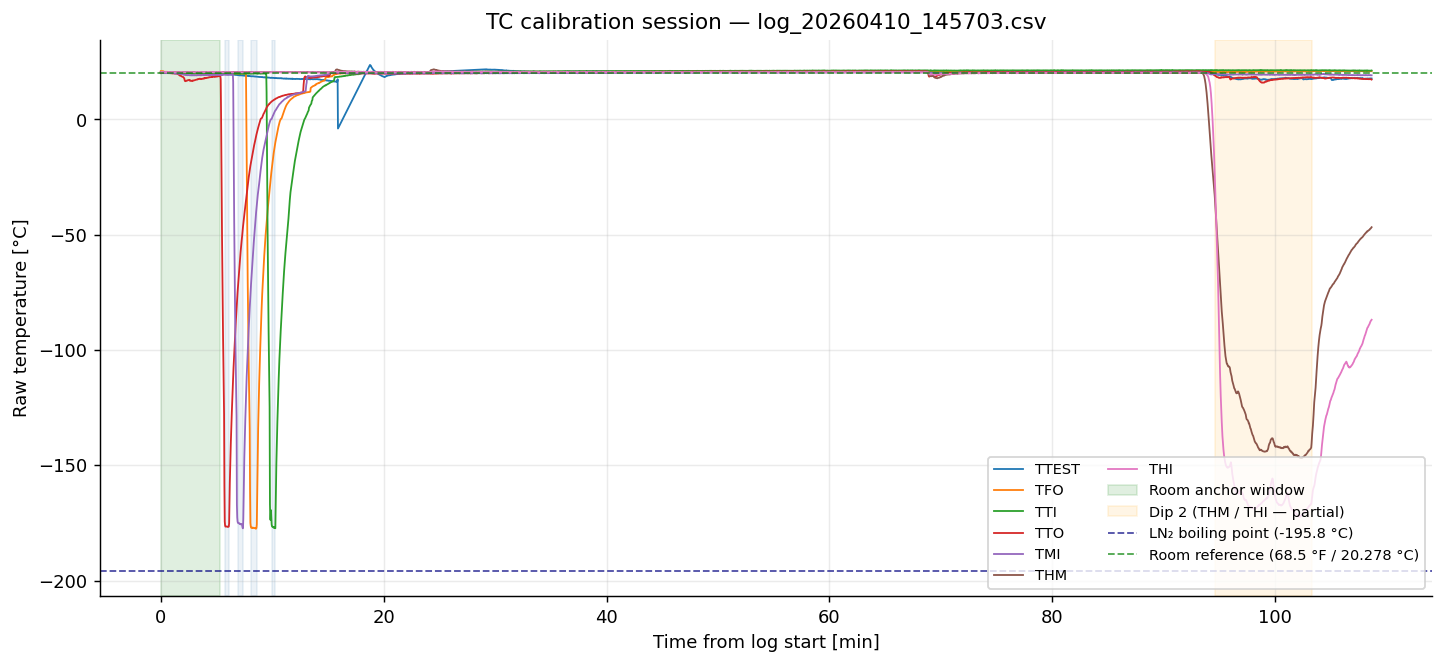

In [3]:
fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)

for col in TC_COLS:
    mask = df[col].notna()
    ax.plot(df.loc[mask, 't_rel_min'], df.loc[mask, col],
            lw=1.0, label=col.replace('_C', ''), color=COLORS[col])

# shade calibration windows
t0 = df['time_s'].iloc[0]
room_span = [(ROOM_WINDOW[0] - t0)/60, (ROOM_WINDOW[1] - t0)/60]
ax.axvspan(*room_span, alpha=0.12, color='green', label='Room anchor window')

for tc, (t_lo, t_hi) in LN_WINDOWS.items():
    ax.axvspan((t_lo - t0)/60, (t_hi - t0)/60, alpha=0.10, color='steelblue')

dip2_span = [(194_100 - t0)/60, (194_620 - t0)/60]
ax.axvspan(*dip2_span, alpha=0.10, color='orange', label='Dip 2 (THM / THI — partial)')

ax.axhline(LN2_BP_C, color='navy', lw=1.0, ls='--', alpha=0.7, label=f'LN₂ boiling point ({LN2_BP_C} °C)')
ax.axhline(ROOM_TRUE_C, color='green', lw=1.0, ls='--', alpha=0.7, label=f'Room reference ({ROOM_TRUE_F:.1f} °F / {ROOM_TRUE_C:.3f} °C)')

ax.set_xlabel('Time from log start [min]')
ax.set_ylabel('Raw temperature [°C]')
ax.set_title('TC calibration session — log_20260410_145703.csv')
ax.legend(loc='lower right', fontsize=8, ncol=2)
plt.show()

## Dip detail — Dip 1 (TTO, TMI, TFO, TTI)

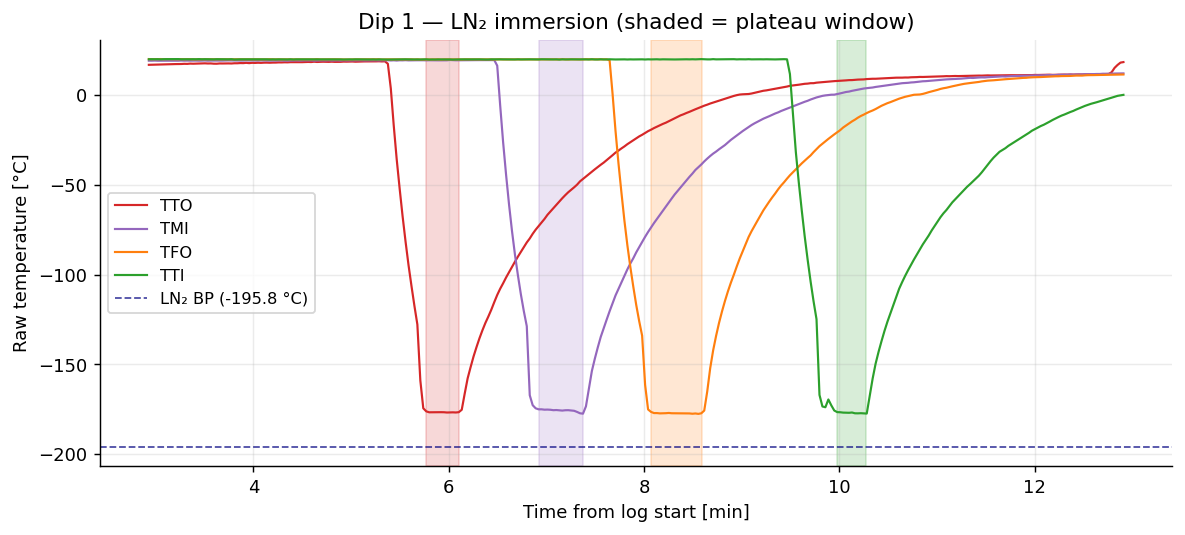

In [4]:
dip1_cols = ['TTO_C', 'TMI_C', 'TFO_C', 'TTI_C']
dip1_mask = (df['time_s'] >= 188_600) & (df['time_s'] <= 189_200)
dip1 = df.loc[dip1_mask].copy()

fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
for col in dip1_cols:
    mask = dip1[col].notna()
    ax.plot(dip1.loc[mask, 't_rel_min'], dip1.loc[mask, col],
            lw=1.2, label=col.replace('_C', ''), color=COLORS[col])

for tc, (t_lo, t_hi) in LN_WINDOWS.items():
    ax.axvspan((t_lo - t0)/60, (t_hi - t0)/60, alpha=0.18, color=COLORS[tc])

ax.axhline(LN2_BP_C, color='navy', lw=1.0, ls='--', alpha=0.7, label=f'LN₂ BP ({LN2_BP_C} °C)')
ax.set_xlabel('Time from log start [min]')
ax.set_ylabel('Raw temperature [°C]')
ax.set_title('Dip 1 — LN₂ immersion (shaded = plateau window)')
ax.legend(fontsize=9)
plt.show()

## Dip detail — Dip 2 (THM, THI — partial immersion)

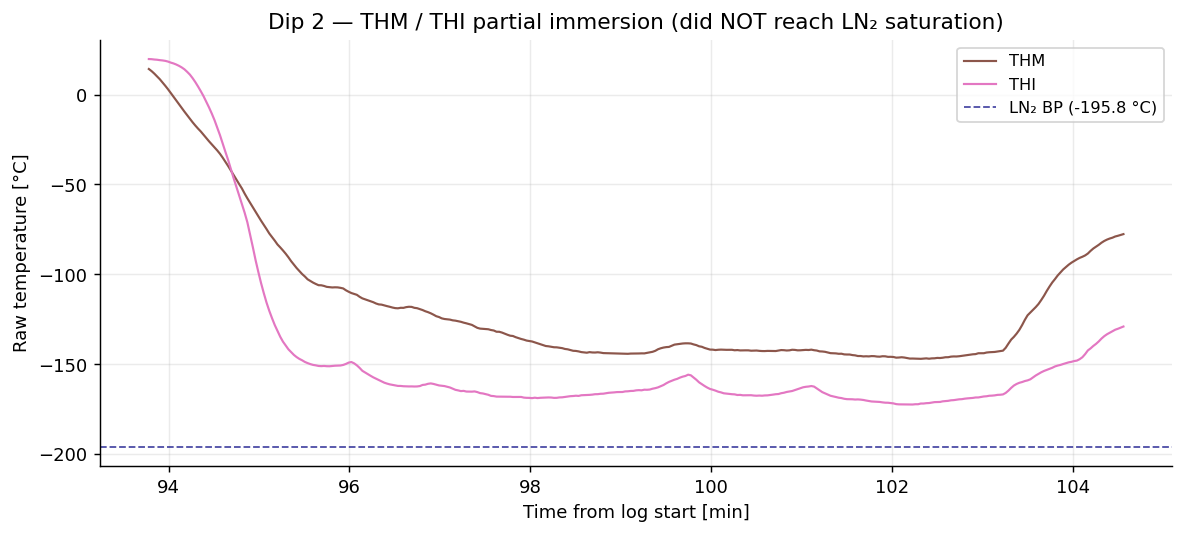

In [5]:
dip2_cols = ['THM_C', 'THI_C']
dip2_mask = (df['time_s'] >= 194_050) & (df['time_s'] <= 194_700)
dip2 = df.loc[dip2_mask].copy()

fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
for col in dip2_cols:
    mask = dip2[col].notna()
    ax.plot(dip2.loc[mask, 't_rel_min'], dip2.loc[mask, col],
            lw=1.2, label=col.replace('_C', ''), color=COLORS[col])

ax.axhline(LN2_BP_C, color='navy', lw=1.0, ls='--', alpha=0.7, label=f'LN₂ BP ({LN2_BP_C} °C)')
ax.set_xlabel('Time from log start [min]')
ax.set_ylabel('Raw temperature [°C]')
ax.set_title('Dip 2 — THM / THI partial immersion (did NOT reach LN₂ saturation)')
ax.legend(fontsize=9)
plt.show()

## Two-point calibration

For each TC with a valid LN plateau:
$$g = \frac{T_\text{LN} - T_\text{room}}{T_\text{raw,LN} - T_\text{raw,room}}, \quad b = T_\text{room} - g \cdot T_\text{raw,room}$$

`THM` and `THI` receive only a room-temperature single-point offset (gain forced to 1).

In [6]:
room_mask = (df['time_s'] >= ROOM_WINDOW[0]) & (df['time_s'] <= ROOM_WINDOW[1])

# Room-temperature raw anchors (median of pre-dip window)
room_raw = {col: float(df.loc[room_mask, col].median()) for col in TC_COLS if col in df.columns}

print('Room raw readings (pre-dip median):')
for col, val in room_raw.items():
    print(f'  {col:<10s}: {val:.3f} °C')

Room raw readings (pre-dip median):
  TTEST_C   : 20.050 °C
  TFO_C     : 20.050 °C
  TTI_C     : 19.990 °C
  TTO_C     : 18.430 °C
  TMI_C     : 19.290 °C
  THM_C     : 20.520 °C
  THI_C     : 20.480 °C


In [7]:
# LN plateau raw anchors
ln_raw = {}
for col, (t_lo, t_hi) in LN_WINDOWS.items():
    mask = (df['time_s'] >= t_lo) & (df['time_s'] <= t_hi)
    ln_raw[col] = float(df.loc[mask, col].median())

print('LN₂ plateau raw readings (stable window median):')
for col, val in ln_raw.items():
    print(f'  {col:<10s}: {val:.3f} °C  (offset from LN₂ BP: {val - LN2_BP_C:+.2f} °C)')

LN₂ plateau raw readings (stable window median):
  TTO_C     : -176.590 °C  (offset from LN₂ BP: +19.21 °C)
  TMI_C     : -175.460 °C  (offset from LN₂ BP: +20.34 °C)
  TFO_C     : -177.200 °C  (offset from LN₂ BP: +18.60 °C)
  TTI_C     : -176.855 °C  (offset from LN₂ BP: +18.95 °C)


In [8]:
records = []

for col in TC_COLS:
    if col not in room_raw or np.isnan(room_raw[col]):
        continue

    raw_room = room_raw[col]
    room_offset = ROOM_TRUE_C - raw_room

    if col in LN_WINDOWS:
        raw_ln = ln_raw[col]
        gain = (LN2_BP_C - ROOM_TRUE_C) / (raw_ln - raw_room)
        offset = ROOM_TRUE_C - gain * raw_room
        cal_type = 'two-point'
        # verification
        check_room = gain * raw_room + offset
        check_ln   = gain * raw_ln   + offset
    elif col in NO_LN_CHANNELS:
        gain   = 1.0
        offset = room_offset
        raw_ln = float('nan')
        cal_type = 'room-only'
        check_room = raw_room + offset
        check_ln   = float('nan')
    else:
        # TTEST_C — not dipped in this session, room offset only
        gain   = 1.0
        offset = room_offset
        raw_ln = float('nan')
        cal_type = 'room-only'
        check_room = raw_room + offset
        check_ln   = float('nan')

    records.append({
        'TC':            col.replace('_C', ''),
        'raw_room_C':    raw_room,
        'raw_ln_C':      raw_ln,
        'gain':          gain,
        'offset_C':      offset,
        'cal_type':      cal_type,
        'check_room_C':  check_room,
        'check_ln_C':    check_ln,
    })

cal = pd.DataFrame(records)

display_cols = ['TC', 'raw_room_C', 'raw_ln_C', 'gain', 'offset_C', 'cal_type']
print(cal[display_cols].to_string(index=False, float_format='{:.4f}'.format))

   TC  raw_room_C  raw_ln_C   gain  offset_C  cal_type
TTEST     20.0500       NaN 1.0000    0.2278 room-only
  TFO     20.0500 -177.2000 1.0955   -1.6860 two-point
  TTI     19.9900 -176.8550 1.0977   -1.6653 two-point
  TTO     18.4300 -176.5900 1.1080   -0.1422 two-point
  TMI     19.2900 -175.4600 1.1095   -1.1247 two-point
  THM     20.5200       NaN 1.0000   -0.2422 room-only
  THI     20.4800       NaN 1.0000   -0.2022 room-only


## Calibration curves

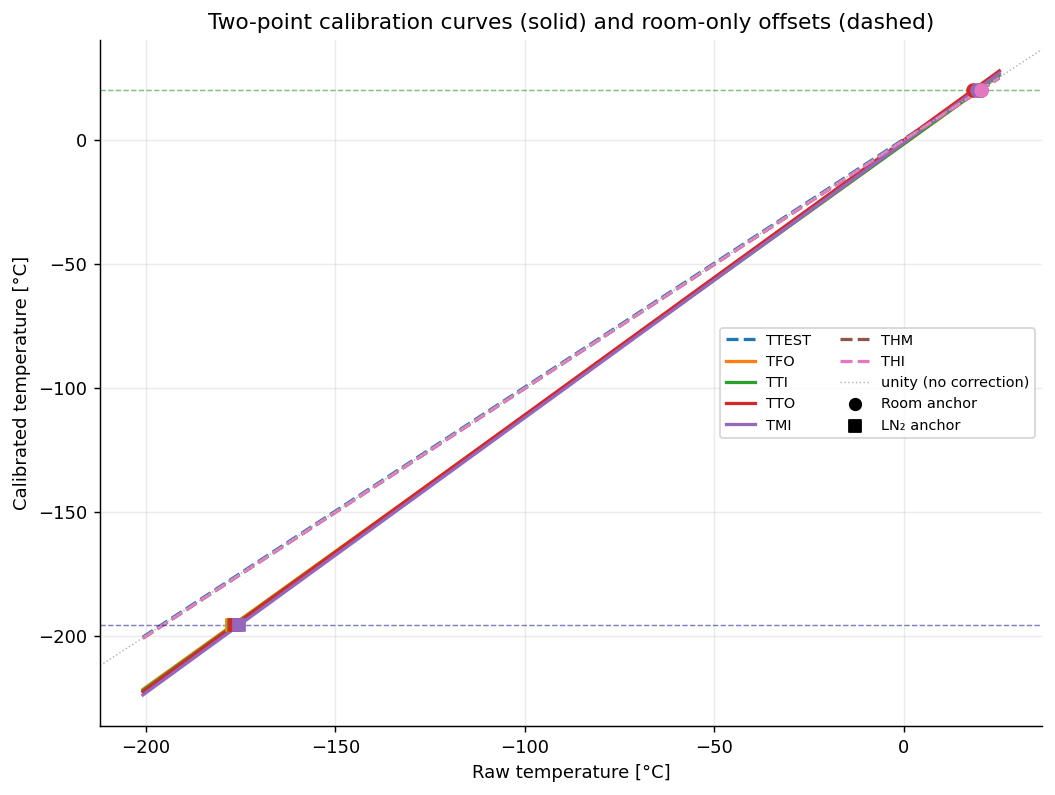

In [9]:
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

raw_grid = np.linspace(LN2_BP_C - 5, ROOM_TRUE_C + 5, 300)

for _, row in cal.iterrows():
    tc   = row['TC']
    col  = tc + '_C'
    cal_line = row['gain'] * raw_grid + row['offset_C']
    ls = '--' if row['cal_type'] == 'room-only' else '-'
    ax.plot(raw_grid, cal_line, lw=1.8, ls=ls, color=COLORS.get(col, 'grey'), label=tc)

    # room anchor
    ax.scatter(row['raw_room_C'], ROOM_TRUE_C, color=COLORS.get(col, 'grey'), marker='o', s=50, zorder=4)
    # LN anchor
    if not np.isnan(row['raw_ln_C']):
        ax.scatter(row['raw_ln_C'], LN2_BP_C, color=COLORS.get(col, 'grey'), marker='s', s=50, zorder=4)

ax.axline((0, 0), slope=1.0, color='0.7', lw=0.8, ls=':', label='unity (no correction)')
ax.scatter([], [], marker='o', color='k', s=40, label='Room anchor')
ax.scatter([], [], marker='s', color='k', s=40, label='LN₂ anchor')
ax.axhline(LN2_BP_C, color='navy', lw=0.8, ls='--', alpha=0.5)
ax.axhline(ROOM_TRUE_C, color='green', lw=0.8, ls='--', alpha=0.5)

ax.set_xlabel('Raw temperature [°C]')
ax.set_ylabel('Calibrated temperature [°C]')
ax.set_title('Two-point calibration curves (solid) and room-only offsets (dashed)')
ax.legend(fontsize=8, ncol=2)
plt.show()

## Calibration summary table

In [10]:
from IPython.display import display

summary = cal[['TC', 'gain', 'offset_C', 'cal_type', 'raw_room_C', 'check_room_C', 'raw_ln_C', 'check_ln_C']].copy()
summary['affine_law'] = summary.apply(
    lambda r: f"T_cal = {r['gain']:.5f} × T_raw + ({r['offset_C']:+.3f})", axis=1
)
summary['room_residual_C'] = summary['check_room_C'] - ROOM_TRUE_C
summary['ln_residual_C']   = summary['check_ln_C'] - LN2_BP_C

out = summary[['TC', 'affine_law', 'cal_type', 'room_residual_C', 'ln_residual_C']]
display(out.style.format({'room_residual_C': '{:.4f}', 'ln_residual_C': '{:.4f}'}).hide(axis='index'))

TC,affine_law,cal_type,room_residual_C,ln_residual_C
TTEST,T_cal = 1.00000 × T_raw + (+0.228),room-only,0.0000,nan
TFO,T_cal = 1.09545 × T_raw + (-1.686),two-point,0.0000,0.0000
TTI,T_cal = 1.09771 × T_raw + (-1.665),two-point,0.0000,0.0000
TTO,T_cal = 1.10798 × T_raw + (-0.142),two-point,0.0000,0.0000
TMI,T_cal = 1.10951 × T_raw + (-1.125),two-point,0.0000,-0.0000
THM,T_cal = 1.00000 × T_raw + (-0.242),room-only,0.0000,nan
THI,T_cal = 1.00000 × T_raw + (-0.202),room-only,0.0000,nan


## Apply calibration and verify

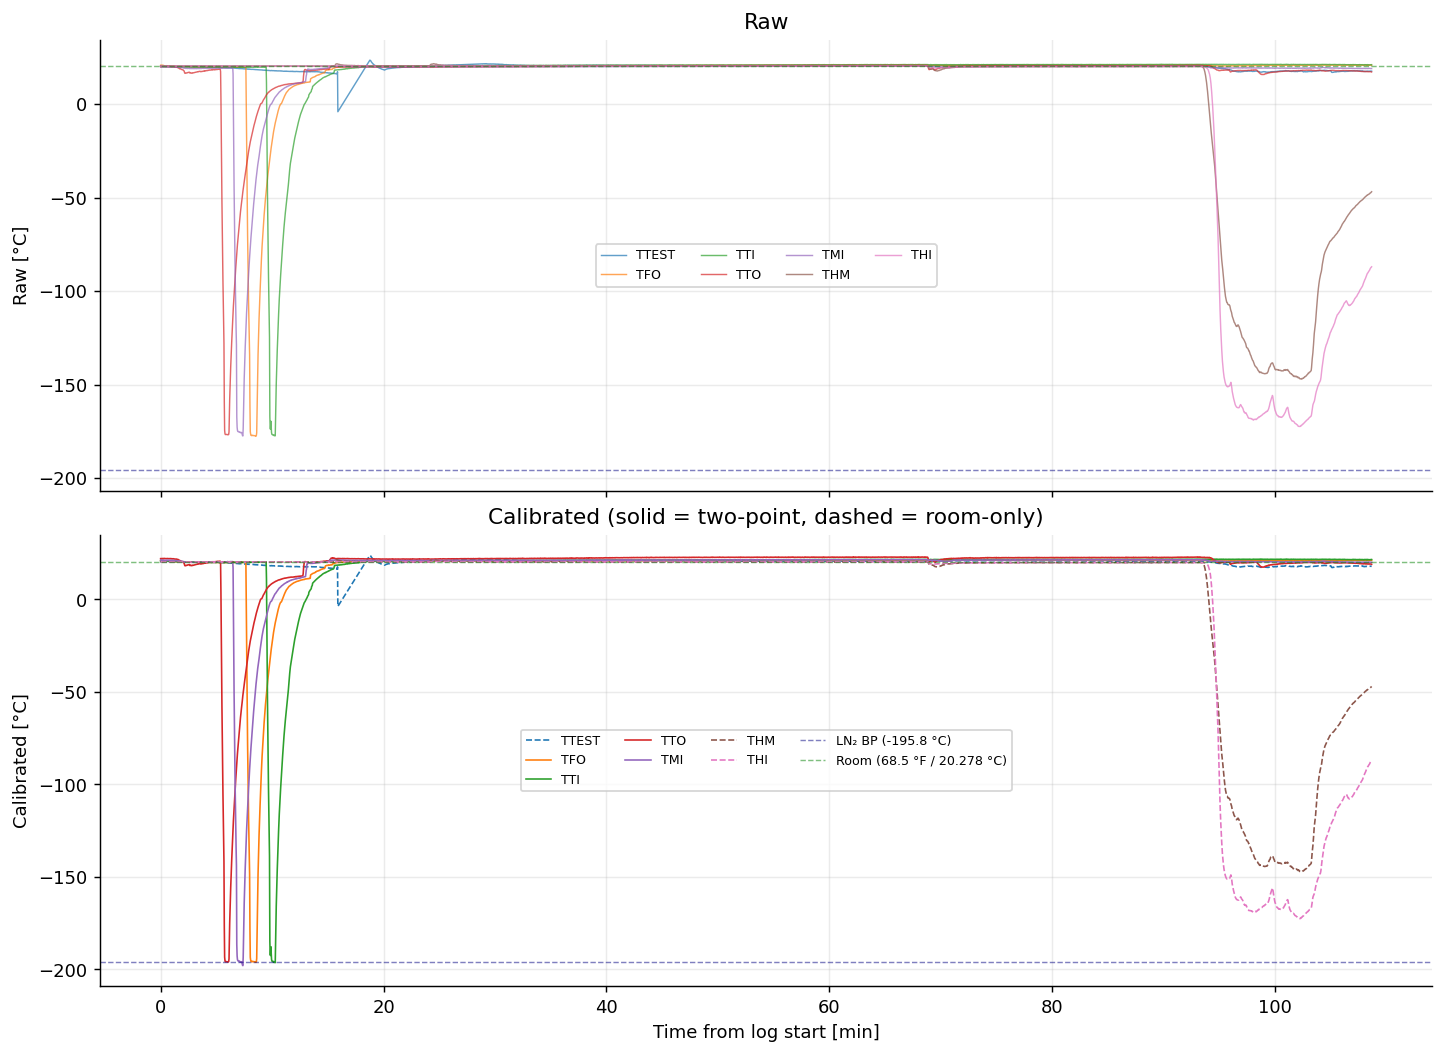

In [11]:
df_cal = df.copy()
for _, row in cal.iterrows():
    col     = row['TC'] + '_C'
    col_cal = row['TC'] + '_cal_C'
    df_cal[col_cal] = row['gain'] * df_cal[col] + row['offset_C']

cal_cols = [row['TC'] + '_cal_C' for _, row in cal.iterrows()]

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True, constrained_layout=True)

# raw
ax = axes[0]
for col in TC_COLS:
    mask = df_cal[col].notna()
    ax.plot(df_cal.loc[mask, 't_rel_min'], df_cal.loc[mask, col],
            lw=0.8, alpha=0.7, color=COLORS[col], label=col.replace('_C', ''))
ax.axhline(LN2_BP_C, color='navy', lw=0.8, ls='--', alpha=0.5)
ax.axhline(ROOM_TRUE_C, color='green', lw=0.8, ls='--', alpha=0.5)
ax.set_ylabel('Raw [°C]')
ax.set_title('Raw')
ax.legend(fontsize=7, ncol=4)

# calibrated
ax = axes[1]
for _, row in cal.iterrows():
    col_cal = row['TC'] + '_cal_C'
    col_raw = row['TC'] + '_C'
    mask    = df_cal[col_cal].notna()
    ls = '--' if row['cal_type'] == 'room-only' else '-'
    ax.plot(df_cal.loc[mask, 't_rel_min'], df_cal.loc[mask, col_cal],
            lw=0.9, ls=ls, color=COLORS[col_raw], label=row['TC'])
ax.axhline(LN2_BP_C, color='navy', lw=0.8, ls='--', alpha=0.5, label=f'LN₂ BP ({LN2_BP_C} °C)')
ax.axhline(ROOM_TRUE_C, color='green', lw=0.8, ls='--', alpha=0.5, label=f'Room ({ROOM_TRUE_F:.1f} °F / {ROOM_TRUE_C:.3f} °C)')
ax.set_xlabel('Time from log start [min]')
ax.set_ylabel('Calibrated [°C]')
ax.set_title('Calibrated (solid = two-point, dashed = room-only)')
ax.legend(fontsize=7, ncol=4)

plt.show()

## Export calibration coefficients

In [12]:
export = cal[['TC', 'gain', 'offset_C', 'cal_type']].copy()
export_path = repo_root / 'data' / 'processed' / 'calibration' / 'TC_calibration_20260410.csv'
export_path.parent.mkdir(parents=True, exist_ok=True)
export.to_csv(export_path, index=False)
print(f'Saved → {export_path}')
display(export)

Saved → /home/aamy/Documents/hfe-system/data/processed/TC_calibration_20260410.csv


,TC,gain,offset_C,cal_type
0,TTEST,1.000000,0.227778,room-only
1,TFO,1.095451,-1.686022,two-point
2,TTI,1.097705,-1.665349,two-point
3,TTO,1.107978,-0.142248,two-point
4,TMI,1.109514,-1.124740,two-point
5,THM,1.000000,-0.242222,room-only
6,THI,1.000000,-0.202222,room-only


## April 20, 2026 recalibration — corrected thermocouple types

**Source file:** `log_20260420_111545.csv`

This second calibration run was recorded after fixing the firmware so the installed `T`-type probes are no longer decoded as `K`-type.

- The room anchor uses the flat tail of the log (last 5 minutes) with the measured ambient `68.5 °F = 20.278 °C`.
- `TTEST`, `TFO`, `TMI`, and `TTO` each show a clear LN plateau in this file.
- `TTI` was dipped twice: once with the original probe and then with the longer replacement probe intended for future runs. The exported `TTI` coefficient below uses the **longer** probe.
- In the recorded data, `THM` and `THI` still do **not** show an LN plateau, so this log can only provide room-anchor offsets for those channels.


In [ ]:
CAL_LOG_NEW = repo_root / 'data' / 'raw' / 'calibration' / 'log_20260420_111545.csv'

ROOM_TRUE_F_NEW = 68.5
ROOM_TRUE_C_NEW = (ROOM_TRUE_F_NEW - 32.0) * 5.0 / 9.0
ROOM_WINDOW_DURATION_S_NEW = 300.0  # fit room anchor from the flat end-of-log segment

TC_COLS_NEW = ['TTEST_C', 'TFO_C', 'TTI_C', 'TTO_C', 'TMI_C', 'THM_C', 'THI_C']
COLORS_NEW = dict(zip(TC_COLS_NEW, ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6']))

LN_WINDOWS_NEW = {
    'TTEST_C': (173.366, 233.590),
    'TFO_C':   (1193.035, 1286.489),
    'TMI_C':   (1805.669, 1886.661),
    'TTO_C':   (2586.518, 2661.280),
}
TTI_WINDOWS_NEW = {
    'TTI_original': (3290.528, 3371.522),
    'TTI_long':     (3587.502, 3668.493),
}
EXPORT_LN_WINDOWS_NEW = {
    **LN_WINDOWS_NEW,
    'TTI_C': TTI_WINDOWS_NEW['TTI_long'],
}
ROOM_ONLY_NEW = ['THM_C', 'THI_C']


df_new = pd.read_csv(CAL_LOG_NEW)
df_new['time_s'] = pd.to_numeric(df_new['time_s'], errors='coerce')
for col in [*TC_COLS_NEW, 'fluid_temperature_c']:
    if col in df_new.columns:
        df_new[col] = pd.to_numeric(df_new[col], errors='coerce')

df_new = df_new.dropna(subset=['time_s']).sort_values('time_s').reset_index(drop=True)
df_new['t_rel_min'] = (df_new['time_s'] - df_new['time_s'].iloc[0]) / 60.0

room_t_hi_new = float(df_new['time_s'].iloc[-1])
room_t_lo_new = room_t_hi_new - ROOM_WINDOW_DURATION_S_NEW
ROOM_WINDOW_NEW = (room_t_lo_new, room_t_hi_new)

print(f'Rows: {len(df_new)}')
print(f"Time range: {df_new['time_s'].iloc[0]:.3f} – {df_new['time_s'].iloc[-1]:.3f} s")
print(f"Duration: {df_new['t_rel_min'].iloc[-1]:.1f} min")
print(f"Room window (flat tail): {ROOM_WINDOW_NEW[0]:.3f} – {ROOM_WINDOW_NEW[1]:.3f} s")
print(f"Room reference: {ROOM_TRUE_F_NEW:.1f} °F / {ROOM_TRUE_C_NEW:.3f} °C")


In [ ]:
fig, ax = plt.subplots(figsize=(12, 5.5), constrained_layout=True)

for col in TC_COLS_NEW:
    mask = df_new[col].notna()
    ax.plot(
        df_new.loc[mask, 't_rel_min'],
        df_new.loc[mask, col],
        lw=1.0,
        color=COLORS_NEW[col],
        label=col.replace('_C', ''),
    )

ax.axvspan(
    (ROOM_WINDOW_NEW[0] - df_new['time_s'].iloc[0]) / 60.0,
    (ROOM_WINDOW_NEW[1] - df_new['time_s'].iloc[0]) / 60.0,
    alpha=0.12,
    color='green',
    label='Room anchor (flat end segment)',
)
for tc, (t_lo, t_hi) in LN_WINDOWS_NEW.items():
    ax.axvspan(
        (t_lo - df_new['time_s'].iloc[0]) / 60.0,
        (t_hi - df_new['time_s'].iloc[0]) / 60.0,
        alpha=0.12,
        color=COLORS_NEW[tc],
    )
for label, (t_lo, t_hi) in TTI_WINDOWS_NEW.items():
    ax.axvspan(
        (t_lo - df_new['time_s'].iloc[0]) / 60.0,
        (t_hi - df_new['time_s'].iloc[0]) / 60.0,
        alpha=0.12,
        color='tab:purple' if label == 'TTI_long' else 'tab:orange',
    )

ax.axhline(LN2_BP_C, color='navy', lw=1.0, ls='--', alpha=0.7, label=f'LN₂ boiling point ({LN2_BP_C} °C)')
ax.axhline(ROOM_TRUE_C_NEW, color='green', lw=1.0, ls='--', alpha=0.7, label=f'Room reference ({ROOM_TRUE_F_NEW:.1f} °F / {ROOM_TRUE_C_NEW:.3f} °C)')
ax.set_xlabel('Time from log start [min]')
ax.set_ylabel('Raw temperature [°C]')
ax.set_title('TC calibration session — log_20260420_111545.csv')
ax.legend(loc='lower right', fontsize=8, ncol=2)
plt.show()


In [ ]:
room_mask_new = df_new['time_s'].between(*ROOM_WINDOW_NEW)
room_raw_new = {
    col: float(df_new.loc[room_mask_new, col].median())
    for col in TC_COLS_NEW
    if col in df_new.columns
}
flow_room_new = float(df_new.loc[room_mask_new, 'fluid_temperature_c'].median()) if 'fluid_temperature_c' in df_new.columns else float('nan')

print('Room raw readings (flat tail median):')
for col, val in room_raw_new.items():
    print(f'  {col:<10s}: {val:.3f} °C')
print(f'  flow meter : {flow_room_new:.3f} °C')

probe_rows_new = []
for tc, window in LN_WINDOWS_NEW.items():
    mask = df_new['time_s'].between(*window)
    raw_ln = float(df_new.loc[mask, tc].median())
    raw_room = room_raw_new[tc]
    gain = (LN2_BP_C - ROOM_TRUE_C_NEW) / (raw_ln - raw_room)
    offset = ROOM_TRUE_C_NEW - gain * raw_room
    probe_rows_new.append({
        'probe': tc.replace('_C', ''),
        'column': tc,
        'window_start_s': window[0],
        'window_end_s': window[1],
        'raw_room_C': raw_room,
        'raw_ln_C': raw_ln,
        'gain': gain,
        'offset_C': offset,
        'note': 'single production probe',
    })

for label, window in TTI_WINDOWS_NEW.items():
    mask = df_new['time_s'].between(*window)
    raw_ln = float(df_new.loc[mask, 'TTI_C'].median())
    raw_room = room_raw_new['TTI_C']
    gain = (LN2_BP_C - ROOM_TRUE_C_NEW) / (raw_ln - raw_room)
    offset = ROOM_TRUE_C_NEW - gain * raw_room
    probe_rows_new.append({
        'probe': 'TTI',
        'column': 'TTI_C',
        'window_start_s': window[0],
        'window_end_s': window[1],
        'raw_room_C': raw_room,
        'raw_ln_C': raw_ln,
        'gain': gain,
        'offset_C': offset,
        'note': 'original probe' if label == 'TTI_original' else 'long probe (future runs)',
    })

probe_summary_new = pd.DataFrame(probe_rows_new)
display(
    probe_summary_new[['probe', 'note', 'raw_room_C', 'raw_ln_C', 'gain', 'offset_C']]
    .style.format({'raw_room_C': '{:.3f}', 'raw_ln_C': '{:.3f}', 'gain': '{:.5f}', 'offset_C': '{:+.4f}'})
    .hide(axis='index')
)


In [ ]:
records_new = []

for col in TC_COLS_NEW:
    raw_room = room_raw_new[col]
    room_offset = ROOM_TRUE_C_NEW - raw_room

    if col in EXPORT_LN_WINDOWS_NEW:
        t_lo, t_hi = EXPORT_LN_WINDOWS_NEW[col]
        raw_ln = float(df_new.loc[df_new['time_s'].between(t_lo, t_hi), col].median())
        gain = (LN2_BP_C - ROOM_TRUE_C_NEW) / (raw_ln - raw_room)
        offset = ROOM_TRUE_C_NEW - gain * raw_room
        cal_type = 'two-point'
        note = 'TTI long probe' if col == 'TTI_C' else 'April 20 LN plateau'
    elif col in ROOM_ONLY_NEW:
        gain = 1.0
        offset = room_offset
        raw_ln = float('nan')
        cal_type = 'room-only'
        note = 'No LN plateau visible in April 20 log'
    else:
        gain = 1.0
        offset = room_offset
        raw_ln = float('nan')
        cal_type = 'room-only'
        note = 'No LN plateau assigned'

    records_new.append({
        'TC': col.replace('_C', ''),
        'raw_room_C': raw_room,
        'raw_ln_C': raw_ln,
        'gain': gain,
        'offset_C': offset,
        'cal_type': cal_type,
        'note': note,
    })

cal_new = pd.DataFrame(records_new)

display(
    cal_new[['TC', 'gain', 'offset_C', 'cal_type', 'raw_room_C', 'raw_ln_C', 'note']]
    .style.format({'gain': '{:.5f}', 'offset_C': '{:+.4f}', 'raw_room_C': '{:.3f}', 'raw_ln_C': '{:.3f}'})
    .hide(axis='index')
)

export_new = cal_new[['TC', 'gain', 'offset_C', 'cal_type']].copy()
export_path_new = repo_root / 'data' / 'processed' / 'calibration' / 'TC_calibration_20260420.csv'
export_path_new.parent.mkdir(parents=True, exist_ok=True)
export_new.to_csv(export_path_new, index=False)
print(f'Saved → {export_path_new}')
display(export_new)


In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 6.2), constrained_layout=True)

raw_grid_new = np.linspace(LN2_BP_C - 5.0, ROOM_TRUE_C_NEW + 5.0, 400)

for _, row in cal_new.iterrows():
    tc = row['TC']
    col = f'{tc}_C'
    label = 'TTI (long probe)' if row['note'] == 'TTI long probe' else tc
    ls = '--' if row['cal_type'] == 'room-only' else '-'
    ax.plot(
        raw_grid_new,
        row['gain'] * raw_grid_new + row['offset_C'],
        lw=1.8,
        ls=ls,
        color=COLORS_NEW.get(col, '0.4'),
        label=label,
    )
    ax.scatter(row['raw_room_C'], ROOM_TRUE_C_NEW, color=COLORS_NEW.get(col, '0.4'), marker='o', s=50, zorder=4)
    if np.isfinite(row['raw_ln_C']):
        ax.scatter(row['raw_ln_C'], LN2_BP_C, color=COLORS_NEW.get(col, '0.4'), marker='s', s=50, zorder=4)

tti_original = probe_summary_new[probe_summary_new['note'] == 'original probe'].iloc[0]
ax.plot(
    raw_grid_new,
    tti_original['gain'] * raw_grid_new + tti_original['offset_C'],
    lw=1.8,
    ls='-.',
    color=COLORS_NEW['TTI_C'],
    alpha=0.95,
    label='TTI (original probe)',
)
ax.scatter(tti_original['raw_room_C'], ROOM_TRUE_C_NEW, color=COLORS_NEW['TTI_C'], marker='^', s=55, zorder=5)
ax.scatter(tti_original['raw_ln_C'], LN2_BP_C, color=COLORS_NEW['TTI_C'], marker='D', s=50, zorder=5)

ax.axline((0, 0), slope=1.0, color='0.70', lw=0.9, ls=':', label='unity (no correction)')
ax.scatter([], [], marker='o', color='k', s=40, label='Room anchor')
ax.scatter([], [], marker='s', color='k', s=40, label='LN anchor')
ax.scatter([], [], marker='^', color='k', s=40, label='TTI original room anchor')
ax.scatter([], [], marker='D', color='k', s=40, label='TTI original LN anchor')
ax.axhline(LN2_BP_C, color='navy', lw=0.8, ls='--', alpha=0.5)
ax.axhline(ROOM_TRUE_C_NEW, color='green', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel('Raw temperature [°C]')
ax.set_ylabel('Calibrated temperature [°C]')
ax.set_title('April 20 calibration curves (future TTI = long probe)')
ax.legend(fontsize=8, ncol=2)
plt.show()


## Legacy note — older runs with the wrong-type firmware

The April 20 coefficients above are the right reference for **future runs recorded with the corrected per-channel thermocouple types**, using the longer `TTI` probe.

They should **not** be applied directly to older logs recorded while the `T`-type probes were still being decoded as `K`-type in firmware. Those historical temperatures were linearised through the wrong thermocouple table, so recovering them requires a separate remapping from the stored wrong-type temperatures (or the equivalent thermocouple EMF) before any final per-probe offset/gain correction is applied.

The shared flow-log review helpers now do that historical remapping automatically for pre-fix logs: they back-convert the logged wrong-type temperatures to estimated `T`-type values with an effective cold-junction temperature fitted from the old April 10 and new April 20 calibration runs, then room-anchor the loop probes on the warmest stable flow-meter segment in that run.
